<a href="https://colab.research.google.com/github/Taqwa10/Codveda-Data-Analysis-Internship/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Codveda Task: Level 1**

## Task 2: Exploratory Data Analysis (EDA) of the Iris Dataset

## **Project Overview**

This project performs an exploratory data analysis (EDA) on the Iris dataset using Python, Pandas, Matplotlib, and Seaborn. The objective is to understand the distribution of flower measurements, identify relationships between numerical features, compare species characteristics, and uncover patterns through statistical summaries and visualizations.

## Dataset Description

The Iris dataset contains measurements of iris flowers from three different species:

- Setosa
- Versicolor
- Virginica

Each observation includes four numerical features:

- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

The target variable is the flower species.

### Tools Used

 Python - Pandas - NumPy - Matplotlib - Seaborn - Google Colab

In [ ]:
#Importing Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving iris.csv to iris.csv


In [ ]:
df = pd.read_csv('iris.csv')

###**Data Inspection**

In [ ]:
# Dataset Shape and information
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# Missing Values
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [ ]:
# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())
duplicates = df[df.duplicated(keep=False)]
duplicates


Duplicate Rows: 3


,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
34,4.9,3.1,1.5,0.1,setosa
37,4.9,3.1,1.5,0.1,setosa
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [ ]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)
print("DataFrame shape after dropping duplicates:", df.shape)

DataFrame shape after dropping duplicates: (147, 5)


***Summary Statistics***  

Calculating summary metrics (mean, median(50%), mode, standard deviation) across all numerical features

In [ ]:
stats = df.describe().T[['mean','50%','std','min','max']]
stats.rename(columns={'50%':'median'},inplace=True)

In [ ]:
numeric_cols = ['sepal_length','sepal_width','petal_length','petal_width']
stats['mode'] = [df[col].mode()[0] for col in numeric_cols]
print(stats)

                  mean  median       std  min  max  mode
sepal_length  5.856463     5.8  0.829100  4.3  7.9   5.0
sepal_width   3.055782     3.0  0.437009  2.0  4.4   3.0
petal_length  3.780272     4.4  1.759111  1.0  6.9   1.4
petal_width   1.208844     1.3  0.757874  0.1  2.5   0.2


***Visualising and Data Distributions & Relationships***  
Explore distribution and pattern visually using: Histogram, Boxplot, and Scatter plot Charts

In [ ]:
#setting the grid background and sections
sns.set_theme(style="whitegrid")


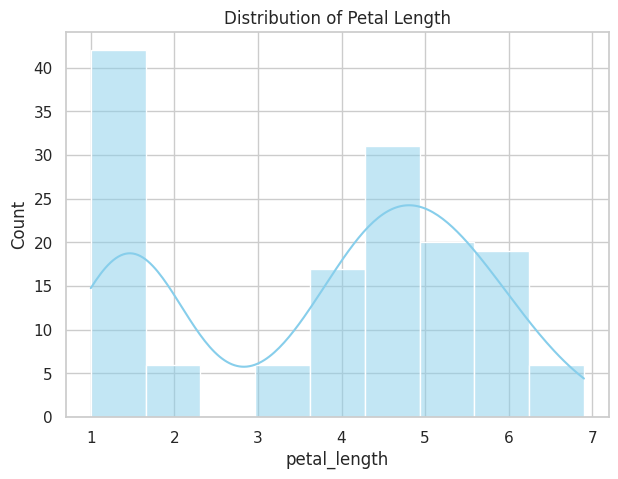

In [ ]:
#Histogram
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='petal_length', kde=True, color='skyblue')
plt.title('Distribution of Petal Length')
plt.show()

### Histogram Interpretation

- Petal length is not evenly distributed across the dataset.
- Most observations are concentrated in two main ranges, indicating a multimodal distribution.
- The distinct peaks suggest that different Iris species have noticeably different petal lengths.
- Petal length appears to be an informative feature for distinguishing between species.

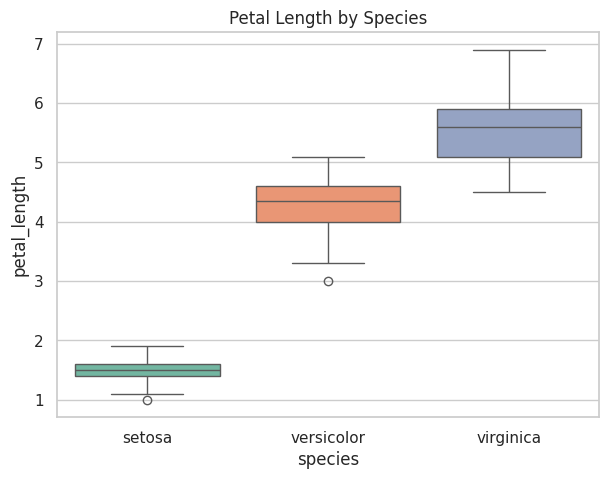

In [ ]:
#Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', hue='species')
plt.title('Petal Length by Species')
plt.show()

### Boxplot Interpretation

- Setosa has the smallest petal lengths, while Virginica has the largest.
- Versicolor falls between the other two species.
- The median petal length increases consistently from Setosa to Versicolor to Virginica.
- A few potential outliers are present, but the overall separation between species remains clear.  

### Insight
Species strongly influences petal length.

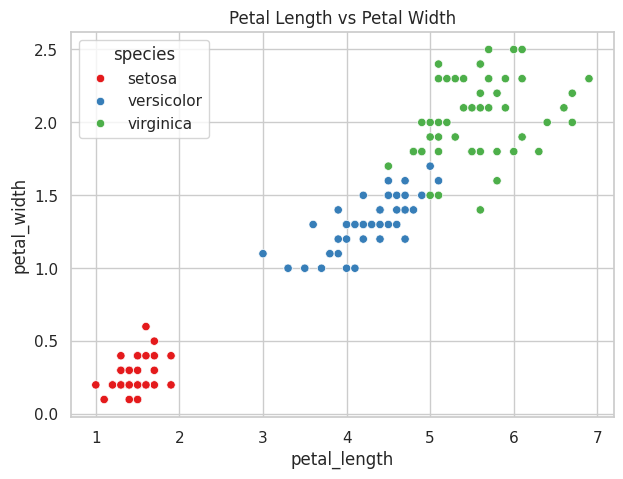

In [ ]:
#Scatter Plot
plt.figure(figsize=(7,5))
sns.scatterplot( data=df, x='petal_length', y='petal_width', hue='species', palette='Set1')
plt.title('Petal Length vs Petal Width')
plt.show()

### Scatter Plot Interpretation

- Petal length and petal width have a strong positive relationship.
- As petal length increases, petal width generally increases as well.
- The three Iris species form distinct clusters based on these two measurements.
- Setosa is completely separated from the other species, while Versicolor and Virginica show only slight overlap.

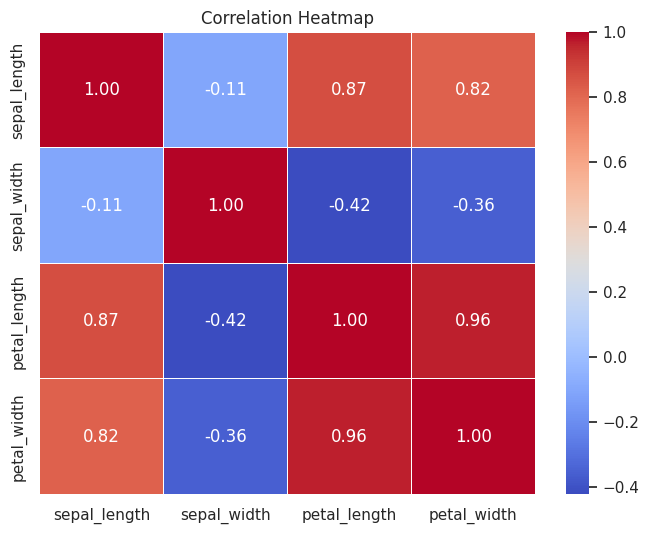

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.drop(columns=['species'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Correlation Heatmap Interpretation

- Petal length and petal width have the strongest positive correlation (0.96), indicating that flowers with longer petals also tend to have wider petals.
- Sepal length is also positively correlated with petal measurements (0.87 and 0.82).
- Sepal width has weak negative correlations with the other numerical variables, suggesting a less consistent relationship.
- Overall, petal measurements appear to be the most informative features in the dataset.

# Key Findings

- Petal measurements vary considerably across Iris species.
- Petal length is one of the strongest distinguishing features among species.
- Petal length and petal width are highly correlated (0.96).
- Setosa is clearly separated from the other two species based on petal measurements.
- The Iris dataset contains well-defined patterns that make it suitable for classification and machine learning tasks.

# Conclusion

The exploratory data analysis revealed clear differences among the three Iris species. Petal length and petal width were identified as the most informative features due to their strong correlation and ability to separate species visually. The visualizations and statistical analysis provide a solid understanding of the dataset and demonstrate how EDA can uncover meaningful patterns before applying machine learning models.